# ERP/ERF analysis

This example will show how to use mean-centred PLS for analyzing ERP/ERF data. We will use the MNE example data, in which a single participant viewed visual stimuli presented to the left or right visual field, or heard auditory stimuli presented to the left or right ear. Following the MNE example [here](https://mne.tools/stable/auto_tutorials/evoked/30_eeg_erp.html), we will compare the left visual and auditory stimuli.

## Loading the data

We will begin by loading the necessary libraries and epoching the data. The details of creating epochs are covered in the MNE example.

In [1]:
import mne
import mne_plsc

sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file)
events = mne.find_events(raw, stim_channel="STI 014")
raw.pick(["eeg", "eog"]).load_data()
raw.crop(tmax=90)
events = events[events[:, 0] <= raw.last_samp]
event_dict = {
    "auditory/left": 1,
    "visual/left": 3,
}
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.2, tmax=0.5
)
reject_criteria = dict(eeg=100e-6, eog=200e-6)
epochs = epochs.drop_bad(reject=reject_criteria)

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Finding events on: STI 014


C:\Users\isaac\Projects\mne-plsc\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Reading 0 ... 41699  =      0.000 ...   277.709 secs...
Not setting metadata
61 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 61 events and 106 original time points ...
    Rejecting  epoch based on EEG : ['EEG 001']
    Rejecting  epoch based on EEG : ['EEG 003', 'EEG 007']
    Rejecting  epoch based on EEG : ['EEG 003']
4 bad epochs dropped


<Epochs | 57 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~2.9 MiB, data not loaded,
 'auditory/left': 27
 'visual/left': 30>

To determine which epochs are from which condition, we can use the `get_epoch_labels` function from `mne_plsc.utils`:

In [2]:
labels = mne_plsc.utils.get_epoch_labels(epochs)

Next, we can fit a model to the data and visualize it. Although the labels are within-participant labels, we will provide them as the "between" argument since the unit of observation for a single-subject analysis is trials:

Using data from preloaded Raw for 57 events and 106 original time points ...
Using data from preloaded Raw for 57 events and 106 original time points ...


(<Figure size 640x480 with 3 Axes>,
 array([<Axes: ylabel='Brain score'>,
        <Axes: xlabel='Time (s)', ylabel='Salience'>], dtype=object))

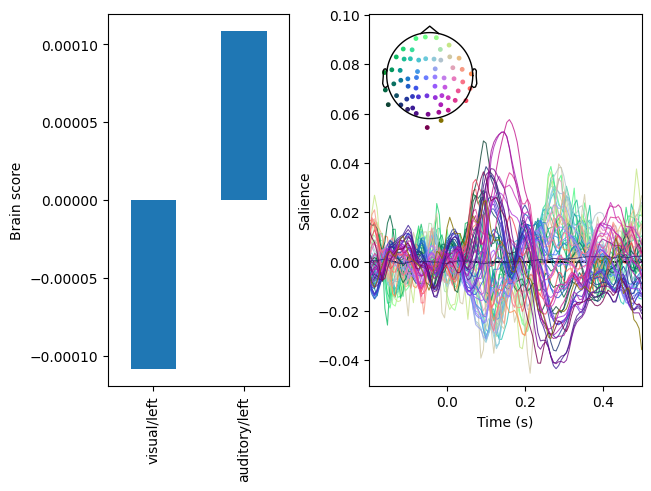

In [3]:
res = mne_plsc.fit_mc(epochs, between=labels, random_state=123)
res.plot_lv(0)

To assess the significance of the model, we can run permutation testing. For speed, we will only do 100 permutations here. For real data, it is advisable to do many more.

Permuting: 100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 229.28it/s]


   LV index  singular value  variance explained   p value
0         0        0.000154                 1.0  0.029703
1         1        0.000000                 0.0       NaN


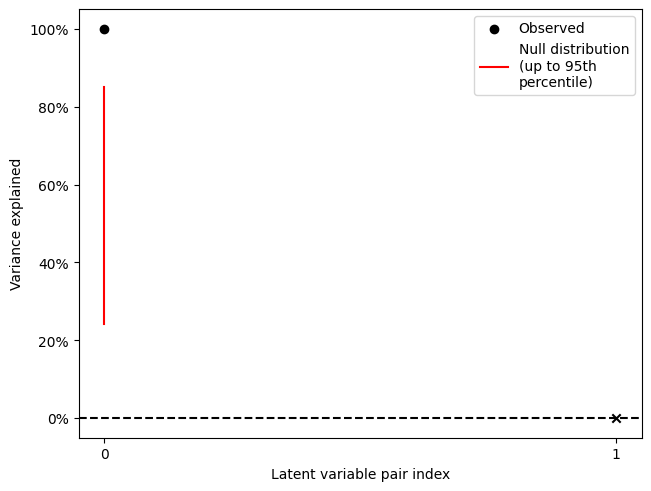

In [4]:
res.permute(100)
print(res.summary())
res.plot_scree()

Thus, the comparison between auditory and visual stimuli is significant. Note that although the decomposition yields 2 latent variable pairs, the second $p$ value is NA (corresponding to the "x" on the scree plot). This is because the rank of the decomposed matrix is one for this mean-centred analysis due to the mean-centering step.

To characterize the latent variable pair, we can run bootstrap resampling and cluster the $z$ scores. For speed, we will run 100 resamples; for real data, it would be advisable to do many more.

In [5]:
res.bootstrap(100)

Resampling: 100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 138.28it/s]


Before cluster analysis, it is necessary to add an adjacency matrix to the data. In the case of ERP analysis, it generally makes sense to treat all channels as adjacent in order to detect multi-channel patterns. This is the default behaviour of `.add_adjacency()` but can be changed with the `all_channels_adjacent` argument.

In [6]:
res.add_adjacency()
res.cluster(threshold=5, which='z-scores')

Defaulting to all channels adjacent for ERP/ERF analysis
Defaulting to unsigned clustering for ERP/ERF analysis
Computing clusters for lv_idx 0...
4 clusters
Computing clusters for lv_idx 1...
0 clusters


Plotting the cluster sizes shows us that there are two major clusters:

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

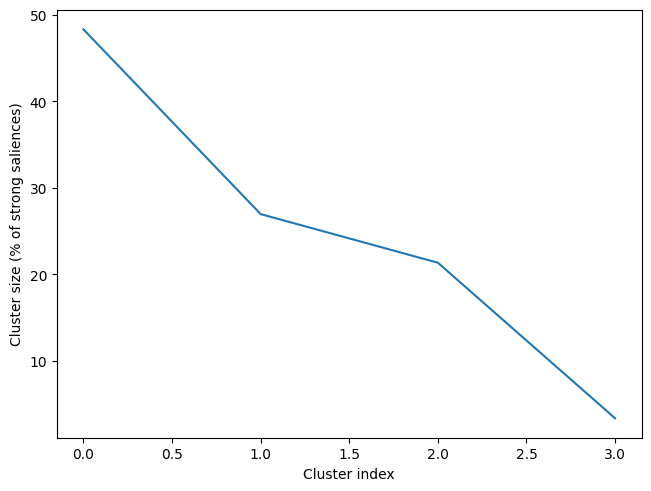

In [7]:
res.plot_cluster_sizes(lv_idx=0)

We can plot both of them using the `.plot_clusters()` method. Note the similarity of the topomaps here to those in the [MNE tutorial](https://mne.tools/stable/auto_tutorials/evoked/30_eeg_erp.html#comparing-conditions).

ValueError: Number of channels in the Info object (60) and the data array (61) do not match. Pick the Info object (e.g., using mne.pick_info and mne.channel_indices_by_type).

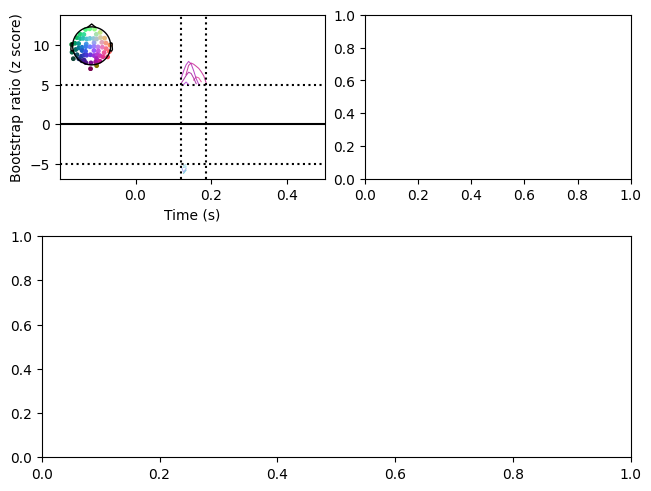

In [8]:
res.plot_clusters(lv_idx=0, cluster_idx=[0, 1])

To see when the two conditions are most strongly differentiated, we can plot the "temporal brain scores":

In [ ]:
res.plot_marginal_brain_scores(0, 'time')